# A/B Testing Analysis for Marketing Campaign Optimization

## Introduction

This project performs an A/B test analysis on a marketing dataset to evaluate whether showing ads improves user conversion rates compared to a control group. 

## Problem Statement

The goal is to determine wheter the observed difference in conversion rates between the AD group and PSA group is statistically significant.

In [6]:
# Installing Libraries #
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Loading

The dataset was loaded using Pandas for further analysis

In [24]:
df  = pd.read_csv("marketing_AB.csv")

## Data Overview
The dataset contains user-level information, including the test group assignment (ad/psa), conversion outcome, and ad exposure details.

In [8]:
df.head

<bound method NDFrame.head of         Unnamed: 0  user id test group  converted  total ads most ads day  \
0                0  1069124         ad      False        130       Monday   
1                1  1119715         ad      False         93      Tuesday   
2                2  1144181         ad      False         21      Tuesday   
3                3  1435133         ad      False        355      Tuesday   
4                4  1015700         ad      False        276       Friday   
...            ...      ...        ...        ...        ...          ...   
588096      588096  1278437         ad      False          1      Tuesday   
588097      588097  1327975         ad      False          1      Tuesday   
588098      588098  1038442         ad      False          3      Tuesday   
588099      588099  1496395         ad      False          1      Tuesday   
588100      588100  1237779         ad      False          1      Tuesday   

        most ads hour  
0                  20

In [9]:
df.info

<bound method DataFrame.info of         Unnamed: 0  user id test group  converted  total ads most ads day  \
0                0  1069124         ad      False        130       Monday   
1                1  1119715         ad      False         93      Tuesday   
2                2  1144181         ad      False         21      Tuesday   
3                3  1435133         ad      False        355      Tuesday   
4                4  1015700         ad      False        276       Friday   
...            ...      ...        ...        ...        ...          ...   
588096      588096  1278437         ad      False          1      Tuesday   
588097      588097  1327975         ad      False          1      Tuesday   
588098      588098  1038442         ad      False          3      Tuesday   
588099      588099  1496395         ad      False          1      Tuesday   
588100      588100  1237779         ad      False          1      Tuesday   

        most ads hour  
0                  

In [10]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [11]:
## Data Distribution Check ##

In [12]:
df['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [13]:
df['converted'].value_counts()

converted
False    573258
True      14843
Name: count, dtype: int64

## Exploratory Data Analysis

In [14]:
## Calculating Mean ##
df.groupby('test group')['converted'].mean()

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

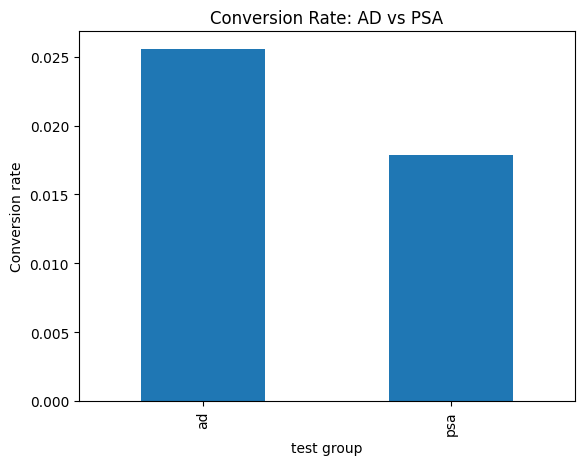

In [15]:
## Visualization##
df.groupby('test group')['converted'].mean().plot(kind='bar')
plt.title("Conversion Rate: AD vs PSA")
plt.ylabel("Conversion rate")
plt.show()

## Hypothesis Testing
H0: AD group conversion rate = PSA group conversion rate

H1: AD group conversion rate > PSA group conversion rate 

A Z-test was used as we are comparing proportions between two independent groups.

In [19]:
##Splitting Data##
control = df[df['test group'] == 'psa']
test = df[df['test group'] == 'ad']

## Z-test

In [20]:
from statsmodels.stats.proportion import proportions_ztest
count = [test['converted'].sum(), control['converted'].sum()]
nobs = [len(test), len(control)]

stat, p_value = proportions_ztest(count, nobs)
print("Z-stat:",stat)
print("P-value:", p_value)

Z-stat: 7.3700781265454145
P-value: 1.7052807161559727e-13


In [25]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis as AD performs significantly better")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis as AD performs significantly better


## Results

The Z-test resulted in a Z-statistic of approximately 7.37 and a P-value close to 0.

Since the p-value is significantly less than 0.05, we reject the null hypothesis

## Conclusion

The AD group has a significantly higher conversion rate compared to the PSA group.

This confirms that Running ADS leads to improved conversions.

The results are statistically robust and provide strong evidence in favour of using ads for improving conversions.

## Business Impact

From a business perspective, this analysis suggests that running ads leads to a measurable and statistically significant increase in conversions.

This insight can help businesses make data-driven decisions regarding marketing investments.